Saving dataset.zip to dataset (16).zip
Files in /content/ → ['.config', 'dataset (12).zip', 'dataset (14).zip', 'dataset (1).zip', 'dataset (9).zip', 'dataset (13).zip', 'dataset (6).zip', 'dataset (8).zip', 'dataset (4).zip', 'dataset (15).zip', 'business.csv', 'dataset (11).zip', 'predicted_vs_actual.png', 'Clean_Dataset.csv', 'economy.csv', 'dataset (10).zip', 'dataset (2).zip', 'dataset (5).zip', 'dataset.zip', 'dataset (16).zip', 'dataset (7).zip', 'dataset (3).zip', 'sample_data']
   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   

  arrival_time destination_city    class  duration  days_left  price  
0        Night           Mumbai  Economy      2.17          1   5953  
1      Morning           Mumbai  Economy      2.33          1   5953  
Columns: ['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time', 'stops', 

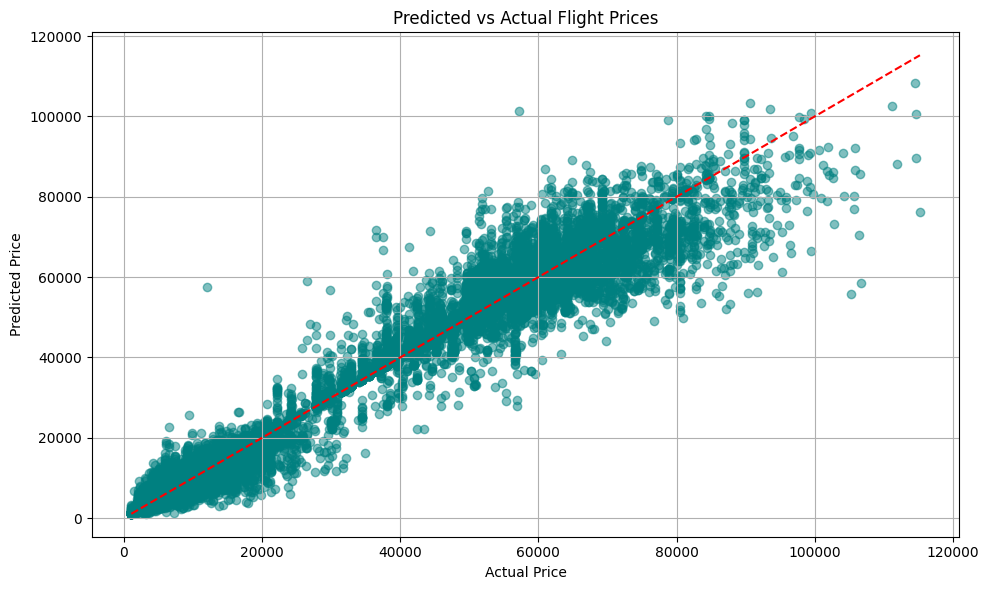

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:

from google.colab import files
uploaded = files.upload()

import zipfile, os, pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, classification_report


zip_path = next(iter(uploaded))
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/')
print("Files in /content/ →", os.listdir('/content/'))


df = pd.read_csv('/content/Clean_Dataset.csv')
print(df.head(2))
print("Columns:", df.columns.tolist())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


df = pd.read_csv("Clean_Dataset.csv")


df.drop(columns=['Unnamed: 0', 'flight'], inplace=True)

print(" Categorical variables.")
categorical_cols = ['airline', 'source_city', 'departure_time',
                    'stops', 'arrival_time', 'destination_city', 'class']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


X = df_encoded.drop('price', axis=1)
y = df_encoded['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


bins = [0, 5000, 10000, np.inf]
labels = ['Low', 'Medium', 'High']
true_labels = pd.cut(y_test, bins=bins, labels=labels)
predicted_labels = pd.cut(y_pred, bins=bins, labels=labels)


cm = confusion_matrix(true_labels, predicted_labels, labels=labels)
cr = classification_report(true_labels, predicted_labels)

print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", cr)

print("Graph")
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Flight Prices")
plt.grid(True)
plt.tight_layout()
plt.show()
from google.colab import files
files.download("predicted_vs_actual.png")